<a href="https://colab.research.google.com/github/hye-lily/in-summer/blob/main/%ED%95%9C%EA%B5%AD%EC%96%B4%EC%96%B4%ED%9C%98%ED%86%B5%EC%82%AC%EB%B6%84%EC%84%9D_2%EC%B0%A8%EC%8B%9C%EC%8B%A4%EC%8A%B5_%EC%A0%95%ED%98%9C%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 한국어 학습자 작문 어휘 분석 2차시

## 학습 목표
- 1차시에서 배운 **어휘 다양도(TTR, MTLD)**를 넘어서, **어휘 정교성(Sophistication)**을 측정한다
- 텍스트의 **어종(한자어/고유어/외래어) 분포**를 분석한다
- **장르(설명문 vs. 네러티브)**에 따라 어휘 사용이 어떻게 달라지는지 비교한다

## 오늘 사용할 데이터
한국어 **학습자 작문 10편** (다양한 주제, 다양한 숙달도)

| 파일 | 주제 | 장르 |
|---|---|---|
| sample_81504 | 역사 인물(김구) | 설명문 |
| sample_81505 | 좋아하는 것과 싫어하는 것 | 네러티브 |
| sample_81506 | 과학 기술의 장단점 | 설명문 |
| sample_81507 | 기후 위기 | 설명문 |
| sample_81508 | 저출산과 고령화 | 설명문 |
| sample_81509 | 역사 인물(칭기스 칸) | 설명문 |
| sample_81510 | 진로 계획(통역사) | 네러티브 |
| sample_81511 | 직업과 진로(번역가) | 네러티브 |
| sample_81512 | 좋아하는 연예인(BTS) | 네러티브 |
| sample_81513 | 좋아하는 취미(그림) | 네러티브 |

## 진행 순서
1. **Part 1**: 어휘 등급별 분석 (초/중/고급)
2. **Part 2**: 어종(한자어/고유어/외래어) 비율 분석
3. **Part 3**: 장르별 비교 및 종합 프로파일
4. **Part 4**: 오류 패턴 자동 탐지

> ✏️ 각 Part 끝에는 **실습 문제**가 있습니다. 직접 풀어보세요!

---


## 0. 환경 설정

오늘 사용할 라이브러리:
- **Kiwi(kiwipiepy)**: 한국어 형태소 분석기
- **pandas**: 데이터 정리
- **matplotlib**: 시각화


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 23.1 MB/s eta 0:00:00


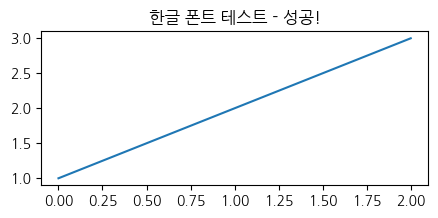

환경 설정 완료!


In [1]:
# 라이브러리 + 한글 폰트 설치
!pip install kiwipiepy -q
!apt-get install -y fonts-nanum -q > /dev/null
!rm -rf /root/.cache/matplotlib

# matplotlib에 폰트 직접 등록 (캐시 안 거치고)
import matplotlib.font_manager as fm
import matplotlib as mpl
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# 기타 라이브러리
import pandas as pd
import numpy as np
from collections import Counter
import re
from kiwipiepy import Kiwi
kiwi = Kiwi()

# 폰트 테스트
plt.figure(figsize=(5,2))
plt.title('한글 폰트 테스트 - 성공!')
plt.plot([1,2,3])
plt.show()

print("환경 설정 완료!")


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from collections import Counter
import re

# 한글 폰트 설정
mpl.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# Kiwi 형태소 분석기
from kiwipiepy import Kiwi
kiwi = Kiwi()

print("환경 설정 완료!")

# 간단한 테스트
test = kiwi.analyze("한국어 분석을 시작합니다.")
print("\nKiwi 테스트:")
for token in test[0][0]:
    print(f"  {token.form} ({token.tag})")


환경 설정 완료!

Kiwi 테스트:
  한국어 (NNP)
  분석 (NNG)
  을 (JKO)
  시작 (NNG)
  하 (XSV)
  ᆸ니다 (EF)
  . (SF)


## 1. 데이터 로드

저장된 학습자 작문 10편을 불러옵니다.


In [3]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import os
import glob

# 데이터 경로: 본인의 파일에서 찾을 것
DATA_DIR = '/content/drive/MyDrive/한국어휘통사분석'

file_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'sample_*.txt')))
print(f"총 {len(file_paths)}개 파일을 찾았습니다.\n")

texts = {}
for fp in file_paths:
    fname = os.path.basename(fp).replace('.txt', '')
    with open(fp, 'r', encoding='utf-8') as f:
        texts[fname] = f.read().strip()
    print(f"  - {fname}: {len(texts[fname])}자")


총 10개 파일을 찾았습니다.

  - sample_81504: 507자
  - sample_81505: 487자
  - sample_81506: 494자
  - sample_81507: 520자
  - sample_81508: 501자
  - sample_81509: 492자
  - sample_81510: 503자
  - sample_81511: 519자
  - sample_81512: 447자
  - sample_81513: 431자


### 메타데이터 입력

10편 모두 **외국인 한국어 학습자**가 쓴 글입니다.
주제와 장르 정보를 함께 저장해 두면, 나중에 장르별/주제별 비교가 쉬워집니다.


In [7]:
# 모든 텍스트가 학습자(L2) 작문
# genre: 설명형(사회·정보 전달) / 자기표현형(개인 경험·취향)
metadata = {
    'sample_81504': {'topic': '역사 인물(김구)',          'genre': '설명형'},
    'sample_81505': {'topic': '좋아하는 것과 싫어하는 것', 'genre': '자기표현형'},
    'sample_81506': {'topic': '과학 기술의 장단점',       'genre': '설명형'},
    'sample_81507': {'topic': '기후 위기',                'genre': '설명형'},
    'sample_81508': {'topic': '저출산과 고령화',          'genre': '설명형'},
    'sample_81509': {'topic': '역사 인물(칭기스 칸)',     'genre': '설명형'},
    'sample_81510': {'topic': '진로 계획(통역사)',        'genre': '자기표현형'},
    'sample_81511': {'topic': '직업과 진로(번역가)',      'genre': '자기표현형'},
    'sample_81512': {'topic': '좋아하는 연예인(BTS)',     'genre': '자기표현형'},
    'sample_81513': {'topic': '좋아하는 취미(그림)',      'genre': '자기표현형'},
}

# '설명형'을 '설명문'으로, '자기표현형'을 '네러티브'로 변환
for sample_id in metadata:
    if metadata[sample_id]['genre'] == '설명형':
        metadata[sample_id]['genre'] = '설명문'
    elif metadata[sample_id]['genre'] == '자기표현형':
        metadata[sample_id]['genre'] = '네러티브'

df_meta = pd.DataFrame.from_dict(metadata, orient='index')
df_meta['text'] = df_meta.index.map(texts)
df_meta['char_count'] = df_meta['text'].str.len()
df_meta

,topic,genre,text,char_count
sample_81504,역사 인물(김구),설명문,"역사적인 사건과 인물들은 각 나라의 발전에 중요한 영향을 미쳤으며, 각 나라의 문화...",507
sample_81505,좋아하는 것과 싫어하는 것,네러티브,모두 사람에게 좋아하는 것과 싫어하는 것이 있다.\n사람들의 생각과 성격이 다르기 ...,487
sample_81506,과학 기술의 장단점,설명문,"현대에 과학 기술이 급속히 발전하고 있다.\n그래서 대부분 사람들은 휴대 전화, 컴...",494
sample_81507,기후 위기,설명문,"기후 위기는 폭염, 폭우, 가뭄, 해수면 상승 등으로 우리 생활에 온 영향을 미친다...",520
sample_81508,저출산과 고령화,설명문,현제 가장 심각한 인구 문제는 저출산과 고령화로 인한 인구 감소와 노동력 부족이다....,501
sample_81509,역사 인물(칭기스 칸),설명문,몽골이 역사적 인물 중 가장 중요한 인물로는 칭기스 칸을 꼽을 수 있다.\n칭기스 ...,492
sample_81510,진로 계획(통역사),네러티브,실력 있는 한국어 통역사가 되는 것을 목표로 10년 계획을 세우고 있다. \n다 양...,503
sample_81511,직업과 진로(번역가),네러티브,"모든 사람은 다른 열정, 추미와 능력을 가지고 있다.\n자신이 진정으로 좋아하는 직...",519
sample_81512,좋아하는 연예인(BTS),네러티브,방탄소년단의 지민과 정국은 케이밥 팬들에게 특별한 존재이다.\n그들은 뛰어난 재능뿐...,447
sample_81513,좋아하는 취미(그림),네러티브,내가 가장 좋아하는 것과 싫어하는 것\n저는 그림 그리는 것을 좋아합니다.\n그림 ...,431


## 2. 형태소 분석 (Kiwi)

### Kiwi 품사 태그 (이번 분석에서 사용하는 것들)
- **NNG**: 일반명사 (예: 사람, 학교, 발전)
- **NNP**: 고유명사 (예: 김구, 몽골)
- **VV**: 동사 (예: 가다, 먹다)
- **VA**: 형용사 (예: 좋다, 예쁘다)
- **MAG**: 일반부사
- **SL**: 외국어/로마자
- **JKO, JX 등**: 조사 (분석에서 제외)
- **EF, EC, ETM 등**: 어미 (분석에서 제외)


In [10]:
def get_content_words(text):
    """
    Kiwi로 형태소 분석 후 내용어만 추출한다.
    명사(NNG, NNP), 동사(VV), 형용사(VA), 부사(MAG)만 사용.
    동사·형용사는 기본형으로 복원 (예: '먹었다' -> '먹다').
    """
    result = kiwi.analyze(text)
    tokens = result[0][0]

    content_pos = {'NNG', 'NNP', 'VV', 'VA', 'MAG', 'SL'}
    content_words = []

    # 제외할 기능 동사 목록
    functional_verbs_to_exclude = {'하다', '되다', '있다'}

    for token in tokens:
        if token.tag in content_pos:
            # 동사·형용사는 기본형(어간)에 '다' 붙이기
            if token.tag in ('VV', 'VA'):
                word = token.form + '다'
            else:
                word = token.form

            # 기능 동사 제외
            if word not in functional_verbs_to_exclude:
                content_words.append((word, token.tag))
    return content_words

# 예시: 첫 텍스트 분석
sample_text = texts['sample_81504']
print("원문(앞 80자):", sample_text[:80])
print("\n내용어 추출 결과 (앞 15개):")
content = get_content_words(sample_text)
for word, tag in content[:15]:
    print(f"  {word} ({tag})")

원문(앞 80자): 역사적인 사건과 인물들은 각 나라의 발전에 중요한 영향을 미쳤으며, 각 나라의 문화를 형성하는 데도 큰 역할을 했습니다.
여기 몇 가지 주요 역

내용어 추출 결과 (앞 15개):
  역사 (NNG)
  사건 (NNG)
  인물 (NNG)
  나라 (NNG)
  발전 (NNG)
  중요 (NNG)
  영향 (NNG)
  미치다 (VV)
  나라 (NNG)
  문화 (NNG)
  형성 (NNG)
  크다 (VA)
  역할 (NNG)
  주요 (NNG)
  역사 (NNG)


### 🔍 실습 문제

위 형태소 분석 결과를 보면 **'하다', '되다', '있다'** 같은 단어가 자주 나옵니다.
이런 동사들은 의미가 약해서 어휘 분석에 큰 도움이 되지 않습니다.

**'하다', '되다' 같은 기능 동사들이 분석 결과에 나오지 않게 처리하려면 어떻게 해야 할까요?**

`get_content_words()` 함수를 수정해서, 이 단어들이 결과에 포함되지 않도록 만들어 보세요.

힌트: 함수 안에 `if` 조건문을 하나 추가하면 됩니다.

In [11]:
# 모든 텍스트에 형태소 분석 적용
df_meta['morphs']      = df_meta['text'].apply(get_content_words)
df_meta['tokens']      = df_meta['morphs'].apply(lambda x: [w for w, t in x])
df_meta['token_count'] = df_meta['tokens'].apply(len)
df_meta['type_count']  = df_meta['tokens'].apply(lambda x: len(set(x)))
df_meta['TTR']         = df_meta['type_count'] / df_meta['token_count']

# 1차시 복습 표
df_meta[['genre', 'topic', 'char_count', 'token_count', 'type_count', 'TTR']].round(3)


,genre,topic,char_count,token_count,type_count,TTR
sample_81504,설명문,역사 인물(김구),507,101,72,0.713
sample_81505,네러티브,좋아하는 것과 싫어하는 것,487,87,45,0.517
sample_81506,설명문,과학 기술의 장단점,494,96,49,0.510
sample_81507,설명문,기후 위기,520,119,92,0.773
sample_81508,설명문,저출산과 고령화,501,110,78,0.709
sample_81509,설명문,역사 인물(칭기스 칸),492,102,79,0.775
sample_81510,네러티브,진로 계획(통역사),503,92,65,0.707
sample_81511,네러티브,직업과 진로(번역가),519,102,75,0.735
sample_81512,네러티브,좋아하는 연예인(BTS),447,81,69,0.852
sample_81513,네러티브,좋아하는 취미(그림),431,75,51,0.680


### 🔍 실습 문제 1

위 표를 보고 다음 질문에 답해 보세요.

**Q1-1.** 토큰 수가 가장 많은 텍스트와 가장 적은 텍스트는 무엇인가요?

**Q1-2.** TTR(어휘다양도)이 가장 높은 텍스트는 무엇이고, 왜 그렇다고 생각하나요?
(힌트: 텍스트 길이와 TTR의 관계를 생각해 보세요)

TTR과 토큰의 관계를 고려해야 함.

In [12]:
# 답을 확인하려면 아래 코드를 실행하세요.
print("토큰 수 정렬:")
print(df_meta[['topic', 'token_count']].sort_values('token_count', ascending=False))
print("\nTTR 정렬:")
print(df_meta[['topic', 'token_count', 'TTR']].sort_values('TTR', ascending=False).round(3))


토큰 수 정렬:
                       topic  token_count
sample_81507           기후 위기          119
sample_81508        저출산과 고령화          110
sample_81509    역사 인물(칭기스 칸)          102
sample_81511     직업과 진로(번역가)          102
sample_81504       역사 인물(김구)          101
sample_81506      과학 기술의 장단점           96
sample_81510      진로 계획(통역사)           92
sample_81505  좋아하는 것과 싫어하는 것           87
sample_81512   좋아하는 연예인(BTS)           81
sample_81513     좋아하는 취미(그림)           75

TTR 정렬:
                       topic  token_count    TTR
sample_81512   좋아하는 연예인(BTS)           81  0.852
sample_81509    역사 인물(칭기스 칸)          102  0.775
sample_81507           기후 위기          119  0.773
sample_81511     직업과 진로(번역가)          102  0.735
sample_81504       역사 인물(김구)          101  0.713
sample_81508        저출산과 고령화          110  0.709
sample_81510      진로 계획(통역사)           92  0.707
sample_81513     좋아하는 취미(그림)           75  0.680
sample_81505  좋아하는 것과 싫어하는 것           87  0.517
sample_81506      과학 기술의 장단점  

## Part 1: 어휘 정교성 분석 (어휘 등급별)

### 개념
- **어휘 다양도**: 얼마나 다양한 단어를 썼는가 (1차시)
- **어휘 정교성**: 얼마나 어렵고 학술적인 단어를 썼는가 (오늘)

같은 TTR이라도 모두 초급 어휘면 정교성이 낮고, 고급 어휘 비중이 높으면 정교성이 높습니다.

### 측정 방법
국립국어원 한국어 학습용 어휘 등급(초/중/고급)에 매칭하여 **등급별 어휘 비율**을 계산합니다.

> ⚠️ 실제 연구에서는 전체 어휘 목록(약 5,000개)을 사용합니다.
> 이 노트북에는 수업 시연용 핵심 어휘(약 600개)만 내장되어 있습니다.
https://kcenter.korean.go.kr/kcenter/ (한국어교수학습셈터)참고


In [13]:
# 어휘 등급 목록 (국립국어원 한국어 학습용 어휘 - 수업용 샘플); 아무리 ttr이 좋아도, 고급 어휘를 많이 사용하지 않으면 아주 좋다고 하기 힘들 수 있음.
BEGINNER_VOCAB = set([
    '사람', '학생', '선생', '친구', '가족', '집', '학교', '회사', '나라', '도시',
    '시간', '날', '요일', '월', '년', '오늘', '내일', '어제', '아침', '점심', '저녁',
    '밥', '물', '음식', '커피', '차', '책', '연필', '가방', '옷', '신발',
    '눈', '코', '입', '귀', '손', '발', '머리', '몸', '얼굴', '마음',
    '꽃', '나무', '하늘', '바다', '산', '강', '길', '방', '문',
    '돈', '값', '가격', '일', '직업', '운동', '영화', '음악', '노래', '춤',
    '말', '글', '이름', '나이', '키', '색', '맛', '향', '소리', '빛',
    '가다', '오다', '먹다', '마시다', '자다', '일어나다', '앉다', '서다', '걷다', '뛰다',
    '보다', '듣다', '말하다', '읽다', '쓰다', '배우다', '가르치다', '공부하다', '일하다', '놀다',
    '좋다', '나쁘다', '크다', '작다', '많다', '적다', '높다', '낮다', '길다', '짧다',
    '있다', '없다', '되다', '하다', '주다', '받다', '사다', '팔다', '만들다','사용하다'
    '알다', '모르다', '생각하다', '느끼다', '원하다', '바라다', '사랑하다', '좋아하다', '싫어하다',
    '예쁘다', '아름답다', '재미있다', '재미없다', '쉽다', '어렵다', '빠르다', '느리다',
    '따뜻하다', '춥다', '덥다', '시원하다', '맛있다', '맛없다', '깨끗하다', '더럽다',
    '아주', '너무', '많이', '조금', '잘', '못', '빨리', '천천히', '항상', '가끔',
    '지금', '먼저', '나중', '같이', '함께', '혼자', '그리고', '그래서', '하지만',
])

INTERMEDIATE_VOCAB = set([
    '관계', '상황', '문제', '방법', '결과', '원인', '이유', '목적', '의미', '내용',
    '경험', '능력', '실력', '노력', '계획', '준비', '목표', '꿈', '희망', '미래',
    '문화', '사회', '경제', '정치', '교육', '환경', '건강', '생활', '습관', '태도',
    '감정', '의견', '주장', '판단', '결정', '선택', '기회', '가능성',
    '발전', '변화', '성장', '향상', '개선', '극복', '해결', '실패', '성공',
    '소통', '대화', '협력', '경쟁', '갈등', '이해', '오해', '신뢰', '존중',
    '도전', '시도', '비교', '구분', '구별',
    '발생하다', '발전하다', '변화하다', '성장하다', '향상되다', '감소하다', '증가하다',
    '시작하다', '끝나다', '계속하다', '멈추다', '진행하다', '준비하다', '완성하다',
    '경험하다', '깨닫다', '인식하다', '판단하다', '결정하다', '선택하다',
    '도전하다', '극복하다', '실패하다', '성공하다', '노력하다', '포기하다',
    '소통하다', '협력하다', '경쟁하다', '비교하다', '구별하다',
    '주장하다', '강조하다', '설명하다', '표현하다', '전달하다', '소개하다',
    '중요하다', '필요하다', '가능하다', '불가능하다', '적절하다', '특별하다',
    '심각하다', '간단하다', '복잡하다', '다양하다', '독특하다', '평범하다',
    '효과적', '효율적', '긍정적', '부정적', '적극적',
    '특히', '대체로', '주로', '대부분', '오히려', '결국', '마침내', '반면',
])

ADVANCED_VOCAB = set([
    '인식', '관념', '개념', '이론', '체계', '구조', '본질', '특성', '속성', '범주',
    '의지', '신념', '가치관', '세계관', '정체성', '주체성', '자율성', '능동성',
    '맥락', '배경', '전제', '근거', '논리', '논거', '명제', '가설', '검증',
    '담론', '서사', '비유', '상징', '함의',
    '국가', '민족', '시민', '주권', '자주', '독립', '해방', '통일', '분단',
    '식민', '제국', '왕조', '봉건', '근대', '계몽', '혁명', '개혁',
    '리더십', '지도력', '통치', '집권', '권력', '정권', '체제', '지도자',
    '온실가스', '탄소', '배출', '감축', '순환', '재생', '지속', '복원',
    '저출산', '고령화', '인구', '부양', '세제', '복지', '균형',
    '자발적', '대규모', '전환점', '시사점', '교훈', '계기', '헌신',
    '미치다', '이끌다', '이루다', '수립하다', '확립하다', '구축하다', '조성하다',
    '가속화', '심화', '강화하다', '약화하다', '확대하다', '축소하다',
    '시행하다', '도입하다', '추진하다', '확보하다', '구현하다', '실현하다',
    '극복하다', '해소하다', '완화하다', '예방하다', '대응하다',
    '이행하다', '준수하다', '위반하다', '저해하다',
    '상징하다', '대표하다', '반영하다', '시사하다', '함축하다',
    '병행하다', '수반하다', '동반하다', '초래하다', '야기하다',
    '필수적', '필연적', '본질적', '근본적', '핵심적',
    '지속적', '체계적', '구조적', '점진적', '급격하다',
    '획기적', '혁신적', '진취적', '능동적', '수동적',
])

print(f"초급 어휘: {len(BEGINNER_VOCAB)}개")
print(f"중급 어휘: {len(INTERMEDIATE_VOCAB)}개")
print(f"고급 어휘: {len(ADVANCED_VOCAB)}개")


초급 어휘: 153개
중급 어휘: 123개
고급 어휘: 132개


In [14]:
def classify_vocabulary(tokens):
    """토큰 리스트를 받아 등급별 비율을 계산한다."""
    counts = {'초급': 0, '중급': 0, '고급': 0, '미분류': 0}
    for token in tokens:
        if token in BEGINNER_VOCAB:
            counts['초급'] += 1
        elif token in INTERMEDIATE_VOCAB:
            counts['중급'] += 1
        elif token in ADVANCED_VOCAB:
            counts['고급'] += 1
        else:
            counts['미분류'] += 1

    total = sum(counts.values())
    ratios = {f'{k}_비율': v / total * 100 for k, v in counts.items()}
    return ratios

vocab_results = df_meta['tokens'].apply(classify_vocabulary)
df_vocab = pd.DataFrame(list(vocab_results), index=df_meta.index)
df_vocab = pd.concat([df_meta[['genre', 'topic']], df_vocab], axis=1)
df_vocab.round(1)


,genre,topic,초급_비율,중급_비율,고급_비율,미분류_비율
sample_81504,설명문,역사 인물(김구),6.9,7.9,22.8,62.4
sample_81505,네러티브,좋아하는 것과 싫어하는 것,47.1,5.7,0.0,47.1
sample_81506,설명문,과학 기술의 장단점,14.6,10.4,3.1,71.9
sample_81507,설명문,기후 위기,2.5,11.8,11.8,73.9
sample_81508,설명문,저출산과 고령화,4.5,10.0,5.5,80.0
sample_81509,설명문,역사 인물(칭기스 칸),2.0,14.7,14.7,68.6
sample_81510,네러티브,진로 계획(통역사),20.7,16.3,0.0,63.0
sample_81511,네러티브,직업과 진로(번역가),21.6,17.6,0.0,60.8
sample_81512,네러티브,좋아하는 연예인(BTS),12.3,8.6,1.2,77.8
sample_81513,네러티브,좋아하는 취미(그림),30.7,0.0,0.0,69.3


In [15]:
# 미분류 단어 확인 - 학생이 직접 보고 분류해 보기
KNOWN_VOCAB = BEGINNER_VOCAB | INTERMEDIATE_VOCAB | ADVANCED_VOCAB

for fname in df_meta.index:
    tokens = df_meta.loc[fname, 'tokens']
    unknown = [w for w in tokens if w not in KNOWN_VOCAB]
    unknown_freq = Counter(unknown).most_common(10)
    print(f"\n[{fname}] {df_meta.loc[fname, 'topic']}")
    print(f"  미분류 단어 (빈도 상위 10개): {unknown_freq}")


[sample_81504] 역사 인물(김구)
  미분류 단어 (빈도 상위 10개): [('인물', 5), ('중요', 4), ('역사', 3), ('사건', 3), ('한국', 3), ('임시', 2), ('정부', 2), ('수립', 2), ('위하다', 2), ('독립운동', 2)]

[sample_81505] 좋아하는 것과 싫어하는 것
  미분류 단어 (빈도 상위 10개): [('경우', 4), ('불편', 4), ('미물', 4), ('때', 3), ('생각', 2), ('다르다', 2), ('가장', 2), ('모두', 1), ('성격', 1), ('따르다', 1)]

[sample_81506] 과학 기술의 장단점
  미분류 단어 (빈도 상위 10개): [('기술', 6), ('사용', 6), ('현대', 4), ('과학', 4), ('단점', 3), ('장점', 3), ('생기다', 3), ('급속히', 2), ('휴대', 2), ('전화', 2)]

[sample_81507] 기후 위기
  미분류 단어 (빈도 상위 10개): [('기후', 5), ('에너지', 4), ('위하다', 3), ('위기', 2), ('사용', 2), ('지구', 2), ('정책', 2), ('같다', 2), ('더불다', 2), ('중립', 2)]

[sample_81508] 저출산과 고령화
  미분류 단어 (빈도 상위 10개): [('출산', 7), ('부담', 5), ('육아', 4), ('고령', 3), ('부족', 3), ('주거', 3), ('지원', 3), ('인하다', 2), ('젊다', 2), ('결혼', 2)]

[sample_81509] 역사 인물(칭기스 칸)
  미분류 단어 (빈도 상위 10개): [('몽골', 4), ('칭기스', 3), ('칸', 3), ('인물', 2), ('중요', 2), ('다양', 2), ('수용', 2), ('평화', 2), ('역사', 1), ('가장', 1)]

[sample_81510] 진로 계획(통역사)
  미분류

### 시각화


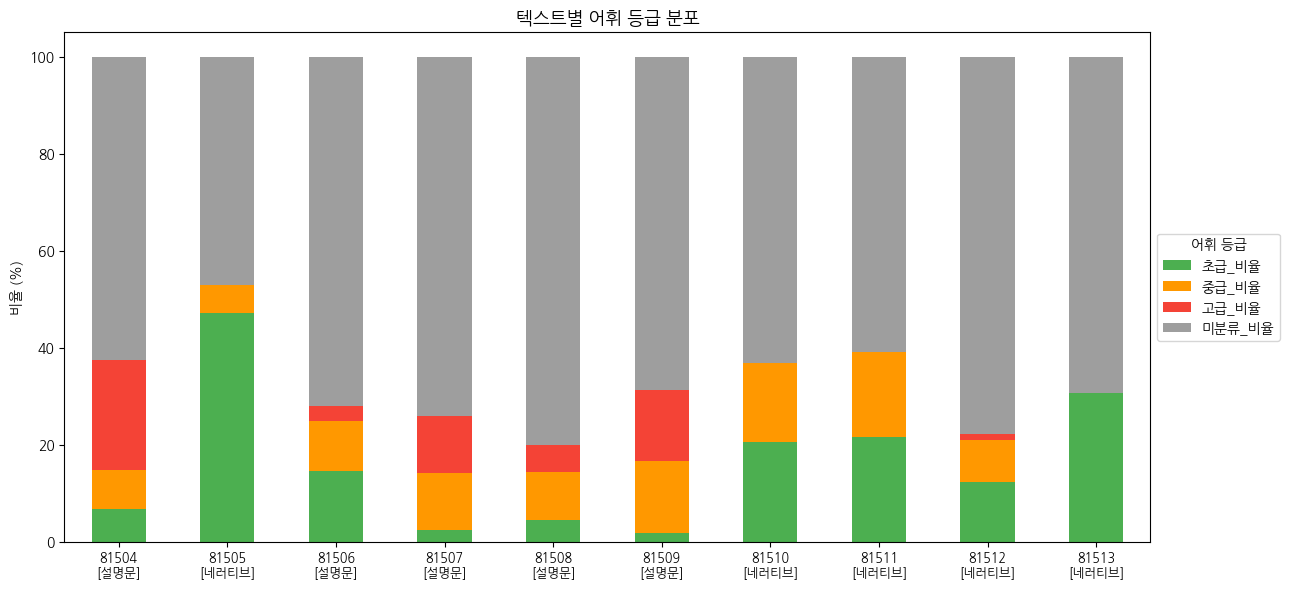

In [16]:
# 텍스트별 어휘 등급 분포 (시각화 코드: 스택 막대그래프)
fig, ax = plt.subplots(figsize=(13, 6))
plot_data = df_vocab[['초급_비율', '중급_비율', '고급_비율', '미분류_비율']]
plot_data.plot(kind='bar', stacked=True, ax=ax,
                color=['#4CAF50', '#FF9800', '#F44336', '#9E9E9E'])
ax.set_title('텍스트별 어휘 등급 분포', fontsize=13)
ax.set_ylabel('비율 (%)')

labels = [f"{idx.replace('sample_', '')}\n[{df_vocab.loc[idx, 'genre']}]"
          for idx in plot_data.index]
ax.set_xticklabels(labels, rotation=0, fontsize=9)
ax.legend(title='어휘 등급', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


장르별 평균 어휘 등급 비율 (%)
       초급_비율  중급_비율  고급_비율
genre                     
네러티브   26.47   9.67   0.25
설명문     6.11  10.96  11.56


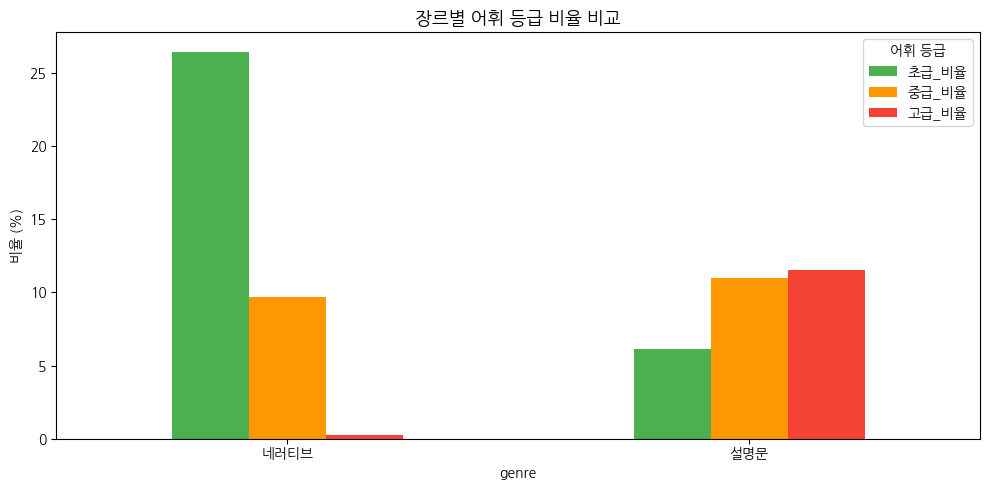

In [17]:
# 장르별 평균 비교
genre_avg = df_vocab.groupby('genre')[['초급_비율', '중급_비율', '고급_비율']].mean()
print("장르별 평균 어휘 등급 비율 (%)")
print(genre_avg.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
genre_avg.plot(kind='bar', ax=ax, color=['#4CAF50', '#FF9800', '#F44336'])
ax.set_title('장르별 어휘 등급 비율 비교', fontsize=13)
ax.set_ylabel('비율 (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='어휘 등급')
plt.tight_layout()
plt.show()


### 🔍 실습 문제 2

**Q2-1.** 위 그래프를 보고, **설명형**과 **자기표현형** 중 어느 장르에서 **고급 어휘 비율**이 더 높게 나타나나요? 왜 그럴 것 같나요?
-> 설명형/장르적 특성

**Q2-2.** **같은 주제**인 81504(역사 - 김구)와 81509(역사 - 칭기스 칸)를 비교해 보세요. 어휘 등급 분포가 비슷한가요, 다른가요? 어느 쪽이 더 고급 어휘를 많이 썼나요?
-> 칭기스 칸

**Q2-3.** '미분류' 비율이 유난히 높은 텍스트가 있다면 어느 것인가요? '미분류'에는 어떤 단어들이 들어 있을지 추측해 보세요.


In [18]:
# Q2-2 답 확인
print("=== 역사 주제 두 편 비교 ===\n")
for idx in ['sample_81504', 'sample_81509']:
    row = df_vocab.loc[idx]
    print(f"[{idx}] {row['topic']}")
    print(f"  초급: {row['초급_비율']:.1f}% | 중급: {row['중급_비율']:.1f}% | "
          f"고급: {row['고급_비율']:.1f}% | 미분류: {row['미분류_비율']:.1f}%\n")


=== 역사 주제 두 편 비교 ===

[sample_81504] 역사 인물(김구)
  초급: 6.9% | 중급: 7.9% | 고급: 22.8% | 미분류: 62.4%

[sample_81509] 역사 인물(칭기스 칸)
  초급: 2.0% | 중급: 14.7% | 고급: 14.7% | 미분류: 68.6%



In [19]:
# Q2-3: 미분류 단어 확인 (학생이 직접 살펴볼 수 있도록)
KNOWN_VOCAB = BEGINNER_VOCAB | INTERMEDIATE_VOCAB | ADVANCED_VOCAB

# 가장 미분류 비율이 높은 텍스트 찾기
top_unknown = df_vocab['미분류_비율'].idxmax()
print(f"미분류 비율이 가장 높은 텍스트: {top_unknown} ({df_vocab.loc[top_unknown, '미분류_비율']:.1f}%)\n")

unknown_tokens = [w for w in df_meta.loc[top_unknown, 'tokens'] if w not in KNOWN_VOCAB]
print(f"미분류 단어 예시 (빈도순, 앞 20개):")
print(Counter(unknown_tokens).most_common(20))


미분류 비율이 가장 높은 텍스트: sample_81508 (80.0%)

미분류 단어 예시 (빈도순, 앞 20개):
[('출산', 7), ('부담', 5), ('육아', 4), ('고령', 3), ('부족', 3), ('주거', 3), ('지원', 3), ('인하다', 2), ('젊다', 2), ('결혼', 2), ('현', 1), ('가장', 1), ('감소', 1), ('노동력', 1), ('증', 1), ('미루다', 1), ('포기', 1), ('출생', 1), ('급감', 1), ('발생', 1)]


## Part 2: 어종 분석 (한자어/고유어/외래어)

### 개념
한국어 어휘는 어원에 따라 세 가지로 나뉩니다:
- **고유어**: 우리말 본래의 어휘 (예: 하늘, 사람, 먹다)
- **한자어**: 한자에서 온 어휘 (예: 학교, 발전, 경제)
- **외래어**: 다른 언어에서 차용한 어휘 (예: 컴퓨터, 인터넷)

학술적·전문적 텍스트일수록 **한자어 비율**이 높아집니다.
같은 학습자라도 어떤 장르를 쓰느냐에 따라 어종 분포가 크게 달라질 수 있습니다.


In [20]:
# 어종 사전 (수업용 샘플)
LOANWORD_LIST = set([
    '컴퓨터', '텔레비전', '핸드폰', '스마트폰', '인터넷', '이메일', '카메라',
    '버스', '택시', '비행기', '엘리베이터', '아파트', '호텔',
    '커피', '주스', '콜라', '피자', '햄버거', '케이크', '아이스크림',
    '티셔츠', '재킷', '코트',
    '뉴스', '드라마', '쇼', '콘서트', '게임', '스포츠',
    '팀', '리더', '매니저', '디자이너', '엔지니어', '팀워크',
    '스트레스', '에너지', '아이디어', '시스템', '프로그램', '데이터', '서비스',
    '아이돌', '팬', '멤버', '앨범', '솔로', '댄스', '랩',
    'AI', '에이아이', '디지털', '온라인', '플랫폼', '콘텐츠',
])

SINO_KOREAN_SAMPLE = set([
    '인물', '사건', '역사', '문화', '발전', '영향', '형성', '역할', '의미', '운동',
    '독립', '정부', '지도자', '해방', '통일', '국가', '수립', '자주', '상징', '교훈',
    '강점기', '대규모', '전환점', '시사점', '헌신', '애국심', '희생', '정신',
    '도전', '성공', '실패', '리더십', '행동', '제공',
    '과학', '기술', '단점', '장점', '사용', '기회', '미래', '습관',
    '현대', '시대', '경제', '정치', '사회', '교육', '환경', '건강', '생활',
    '문제', '해결', '방법', '결과', '원인', '이유', '목적', '내용', '능력', '실력',
    '계획', '준비', '목표', '관계', '상황', '경험', '의견', '판단', '결정', '선택',
    '변화', '성장', '향상', '개선', '극복', '소통', '대화', '협력', '경쟁', '갈등',
    '필요', '가능', '중요', '적절', '특별', '심각', '복잡', '다양', '독특',
    '기후', '위기', '폭염', '폭우', '가뭄', '해수면', '상승', '농업', '생산성',
    '식량', '부족', '자연재해', '빈번', '경제적', '손실', '악화', '온실가스', '배출', '증가',
    '화석', '연료', '벌목', '공장', '차량', '탄소', '지구', '온난화', '가속화', '순환',
    '방해', '친환경', '확대', '감축', '정책', '시행', '개인', '절약', '실천',
    '태양광', '풍력', '재생', '효율', '개발', '중립', '국제적', '협력', '필수적',
    '지속', '교통수단', '전기차', '대중교통', '장려', '복원', '흡수', '책임', '강화',
    '저출산', '고령화', '인구', '노동력', '세대', '결혼', '출산', '포기', '출생률',
    '급감', '발생', '부양', '부담', '가구', '개인주의', '확산', '주거', '비용', '기피',
    '안정적', '일자리', '확보', '사회적', '지원', '조성', '다각적', '접근', '유연',
    '근무제', '휴직', '제도', '장려금', '세제', '혜택',
    '몽골', '제국', '유라시아', '거대', '군사', '유목민',
    '집권', '교류', '문명', '아시아', '유럽', '연결', '통로', '무역', '후세',
    '실크로드', '기여', '강한', '혁신적', '사고', '주도', '통합', '민족', '종교',
    '수용', '평화', '유지', '정복', '조화', '중요성',
    '통역사', '관심', '전문', '대학생', '수업',
    '수강', '자료', '단어', '신문', '분야', '지식', '용어', '정확', '훌륭', '업무', '수행',
    '열정', '진정', '직업', '행복', '번역', '접촉',
    '시간', '압박', '정보', '조직', '어려움', '고객', '언어', '전달', '효과적',
    '장비', '대체', '진행', '동기', '부여', '단계',
    '존재', '재능', '개성', '매력', '사랑',
    '무대', '감정', '관객', '목소리', '곡', '장르', '음악', '역량',
    '진솔', '인기', '집중력', '추천', '활동', '참여', '유익',
])

def detect_word_type(word):
    """단어의 어종을 판별한다."""
    if re.search(r'[a-zA-Z]', word):
        return '외래어'
    if word in LOANWORD_LIST:
        return '외래어'
    if word in SINO_KOREAN_SAMPLE:
        return '한자어'
    return '고유어'

def analyze_word_origin(tokens):
    """어종별 비율 계산."""
    counts = Counter()
    for token in tokens:
        counts[detect_word_type(token)] += 1
    total = sum(counts.values())
    return {f'{k}_비율': counts.get(k, 0) / total * 100
            for k in ['한자어', '고유어', '외래어']}

origin_results = df_meta['tokens'].apply(analyze_word_origin)
df_origin = pd.DataFrame(list(origin_results), index=df_meta.index)
df_origin = pd.concat([df_meta[['genre', 'topic']], df_origin], axis=1)
df_origin.round(1)


,genre,topic,한자어_비율,고유어_비율,외래어_비율
sample_81504,설명문,역사 인물(김구),55.4,44.6,0.0
sample_81505,네러티브,좋아하는 것과 싫어하는 것,8.0,89.7,2.3
sample_81506,설명문,과학 기술의 장단점,38.5,56.2,5.2
sample_81507,설명문,기후 위기,67.2,29.4,3.4
sample_81508,설명문,저출산과 고령화,56.4,43.6,0.0
sample_81509,설명문,역사 인물(칭기스 칸),63.7,36.3,0.0
sample_81510,네러티브,진로 계획(통역사),40.2,57.6,2.2
sample_81511,네러티브,직업과 진로(번역가),52.0,45.1,2.9
sample_81512,네러티브,좋아하는 연예인(BTS),30.9,61.7,7.4
sample_81513,네러티브,좋아하는 취미(그림),14.7,82.7,2.7


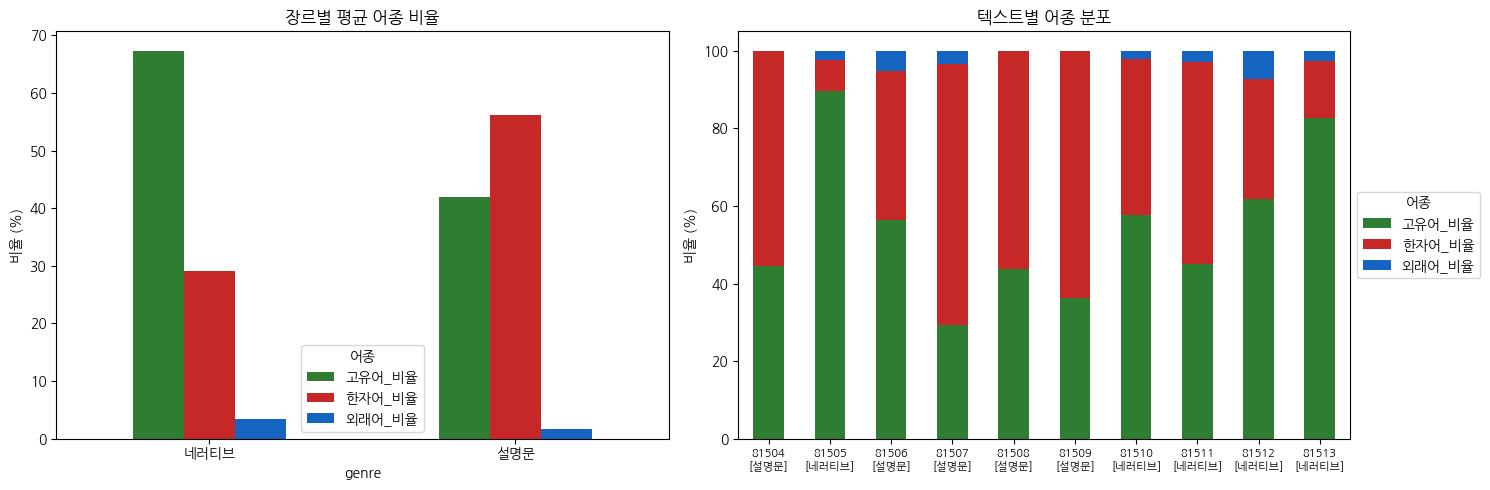


장르별 평균 어종 비율 (%)
       고유어_비율  한자어_비율  외래어_비율
genre                        
네러티브    67.35   29.15    3.50
설명문     42.03   56.26    1.71


In [21]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 좌: 장르별 평균
origin_avg = df_origin.groupby('genre')[['고유어_비율', '한자어_비율', '외래어_비율']].mean()
origin_avg.plot(kind='bar', ax=axes[0], color=['#2E7D32', '#C62828', '#1565C0'])
axes[0].set_title('장르별 평균 어종 비율', fontsize=12)
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='어종')

# 우: 텍스트별
plot_data = df_origin[['고유어_비율', '한자어_비율', '외래어_비율']]
plot_data.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#2E7D32', '#C62828', '#1565C0'])
axes[1].set_title('텍스트별 어종 분포', fontsize=12)
axes[1].set_ylabel('비율 (%)')
labels = [f"{idx.replace('sample_', '')}\n[{df_origin.loc[idx, 'genre']}]"
          for idx in plot_data.index]
axes[1].set_xticklabels(labels, rotation=0, fontsize=8)
axes[1].legend(title='어종', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

print("\n장르별 평균 어종 비율 (%)")
print(origin_avg.round(2))


### 🔍 실습 문제 3

**Q3-1.** **설명형 글**과 **자기표현형 글** 중 어느 쪽에서 **한자어 비율**이 높게 나타나나요? 왜 그럴까요?

**Q3-2.** **외래어 비율**이 가장 높은 텍스트는 무엇이고, 그 이유는 무엇이라고 생각하나요? (해당 텍스트의 주제와 관련지어 설명해 보세요)

**Q3-3.** 같은 학습자가 설명형 글과 자기표현형 글을 쓸 때 어종 분포가 달라진다면, 자동채점 시스템(AWE)은 두 장르를 똑같이 평가해도 될까요? 자유롭게 의견을 말해 보세요.


## Part 3: 종합 프로파일 비교

1차시(어휘 다양도)와 2차시(정교성·어종)의 결과를 모두 합쳐서 종합 프로파일을 만들어 봅니다.


In [22]:
# 종합 데이터프레임( round (2) : 소수점 둘째자리까지 보이게 함.)
df_profile = pd.concat([
    df_meta[['genre', 'topic', 'token_count', 'type_count', 'TTR']],
    df_vocab[['초급_비율', '중급_비율', '고급_비율']],
    df_origin[['고유어_비율', '한자어_비율', '외래어_비율']],
], axis=1)
df_profile.round(2)


,genre,topic,token_count,type_count,TTR,초급_비율,중급_비율,고급_비율,고유어_비율,한자어_비율,외래어_비율
sample_81504,설명문,역사 인물(김구),101,72,0.71,6.93,7.92,22.77,44.55,55.45,0.00
sample_81505,네러티브,좋아하는 것과 싫어하는 것,87,45,0.52,47.13,5.75,0.00,89.66,8.05,2.30
sample_81506,설명문,과학 기술의 장단점,96,49,0.51,14.58,10.42,3.12,56.25,38.54,5.21
sample_81507,설명문,기후 위기,119,92,0.77,2.52,11.76,11.76,29.41,67.23,3.36
sample_81508,설명문,저출산과 고령화,110,78,0.71,4.55,10.00,5.45,43.64,56.36,0.00
sample_81509,설명문,역사 인물(칭기스 칸),102,79,0.77,1.96,14.71,14.71,36.27,63.73,0.00
sample_81510,네러티브,진로 계획(통역사),92,65,0.71,20.65,16.30,0.00,57.61,40.22,2.17
sample_81511,네러티브,직업과 진로(번역가),102,75,0.74,21.57,17.65,0.00,45.10,51.96,2.94
sample_81512,네러티브,좋아하는 연예인(BTS),81,69,0.85,12.35,8.64,1.23,61.73,30.86,7.41
sample_81513,네러티브,좋아하는 취미(그림),75,51,0.68,30.67,0.00,0.00,82.67,14.67,2.67


In [23]:
# 장르별 종합 평균
print("=" * 60)
print("장르별 어휘 프로파일 비교")
print("=" * 60)
summary = df_profile.groupby('genre').mean(numeric_only=True).round(2)
print(summary.T)


장르별 어휘 프로파일 비교
genre         네러티브     설명문
token_count  87.40  105.60
type_count   61.00   74.00
TTR           0.70    0.70
초급_비율        26.47    6.11
중급_비율         9.67   10.96
고급_비율         0.25   11.56
고유어_비율       67.35   42.03
한자어_비율       29.15   56.26
외래어_비율        3.50    1.71


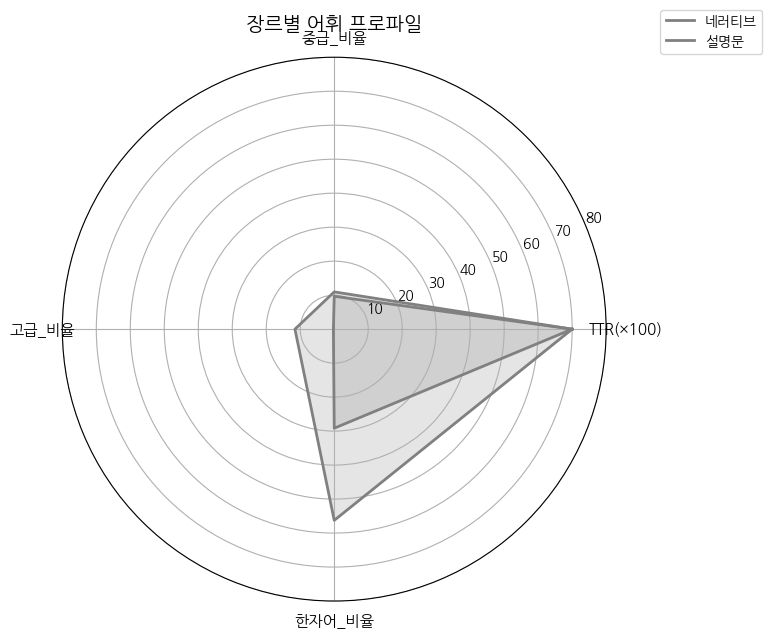

In [24]:
# 레이더 차트
from math import pi

def plot_radar(df_summary, title='장르별 어휘 프로파일'):
    categories = ['TTR(×100)', '중급_비율', '고급_비율', '한자어_비율']
    df_norm = pd.DataFrame({
        'TTR(×100)': df_summary['TTR'] * 100,
        '중급_비율': df_summary['중급_비율'],
        '고급_비율': df_summary['고급_비율'],
        '한자어_비율': df_summary['한자어_비율'],
    })

    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = {'설명형': '#1976D2', '자기표현형': '#D32F2F'}

    for genre in df_norm.index:
        values = df_norm.loc[genre].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=genre,
                color=colors.get(genre, 'gray'))
        ax.fill(angles, values, alpha=0.2, color=colors.get(genre, 'gray'))

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, max(60, df_norm.values.max() + 10))
    ax.set_title(title, size=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_radar(summary)


### 🔍 실습 문제 4
**Q4-1.** 학습자 한 명의 어휘 능력을 평가할 때, **하나의 글**만 보고 판단해도 충분할까요? 본 분석 결과를 근거로 답해 보세요.

-> 불충분함. 한 학습자라도 글의 주제나 장르에 따라 사용하는 어휘가 달라질 것임. 장르별 어휘 비교에서 나타나듯이 설명형 글은 장르적 특성으로 고급 어휘, 한자어 비율이 높으므로, 하나의 글만 보면 해당 장르에 특화된 어휘 능력을 평가하게 됨.

**Q4-2.** 만약 여러분이 자동채점 시스템을 설계한다면, **설명형 글**과 **자기표현형 글**에 같은 채점 기준을 적용할 것 같나요, 다른 기준을 적용할 것 같나요? 그 이유는?

-> 상이한 기준을 적용할 것. 자기표현형 글, 네러티브 장르에 고급어 어휘 사용을 요구하는 기준을 적용하면 낮은 점수를 받게되기 때문임.

**Q4-3.** 본 분석에서 발견된 패턴(예: 설명형 글에서 한자어 비율이 높다, 자기표현형 글에서 외래어가 더 나타난다 등)은 한국어 교육에서 어떻게 활용할 수 있을까요?

-> 어휘 수준 별 맞춤 학습, 균형있는 어휘 습득을 유도할 수 있을 것임. 자동 채점 시스템 발전시킬 수 있음.

## Part 5: 통사 복잡성 지표
### 개념
지금까지는 **어휘**에 초점을 맞췄지만, 글의 수준은 **문장 구조의 복잡성**에서도 드러납니다.

이번 파트에서는 세 가지 통사 복잡성 지표를 측정합니다:
1. **평균 문장 길이 (MLS)**: 한 문장이 평균 몇 어절인가
2. **종결어미 다양도**: '-다', '-요', '-습니다' 등 종결어미를 얼마나 다양하게 쓰는가
3. **연결어미 다양도**: '-고', '-지만', '-아서' 등 연결어미를 얼마나 다양하게 쓰는가

### 왜 중요한가?
- 학습자는 보통 **짧고 단순한 문장**을 쓰고, 종결어미도 '-다' 한 가지에 치우치는 경향이 있습니다
- 숙달도가 올라갈수록 문장이 길어지고, 다양한 어미를 구사하게 됩니다
- AWE 시스템(e-rater, KEEwi 등)에서도 **통사 복잡성**은 핵심 평가 자질입니다

In [ ]:
# 평균 문장 길이 (Mean Length of Sentence, MLS)
# 한 문장당 평균 어절 수로 측정

def measure_sentence_length(text):
    """문장별 어절 수와 평균을 계산한다."""
    # Kiwi의 문장 분리 기능 사용
    sentences = kiwi.split_into_sents(text)
    sent_lengths = []
    for sent in sentences:
        # 어절 수 = 공백 기준 단어 수
        eojeol_count = len(sent.text.split())
        if eojeol_count > 0:
            sent_lengths.append(eojeol_count)

    return {
        '문장수': len(sent_lengths),
        '총어절수': sum(sent_lengths),
        '평균문장길이': np.mean(sent_lengths) if sent_lengths else 0,
        '최대문장길이': max(sent_lengths) if sent_lengths else 0,
        '최소문장길이': min(sent_lengths) if sent_lengths else 0,
    }

# 모든 텍스트에 적용
sent_results = df_meta['text'].apply(measure_sentence_length)
df_sent = pd.DataFrame(list(sent_results), index=df_meta.index)
df_sent = pd.concat([df_meta[['genre', 'topic']], df_sent], axis=1)
df_sent.round(2)

,genre,topic,문장수,총어절수,평균문장길이,최대문장길이,최소문장길이
sample_81504,설명형,역사 인물(김구),9,123,13.67,21,6
sample_81505,자기표현형,좋아하는 것과 싫어하는 것,15,125,8.33,11,6
sample_81506,설명형,과학 기술의 장단점,14,131,9.36,22,3
sample_81507,설명형,기후 위기,10,128,12.80,18,7
sample_81508,설명형,저출산과 고령화,9,128,14.22,22,7
sample_81509,설명형,역사 인물(칭기스 칸),11,123,11.18,16,9
sample_81510,자기표현형,진로 계획(통역사),11,132,12.00,19,6
sample_81511,자기표현형,직업과 진로(번역가),17,130,7.65,15,4
sample_81512,자기표현형,좋아하는 연예인(BTS),12,108,9.00,12,4
sample_81513,자기표현형,좋아하는 취미(그림),12,110,9.17,15,6


In [ ]:
# Kiwi 어미 태그
# EF: 종결어미 (예: -다, -요, -습니다)
# EC: 연결어미 (예: -고, -지만, -아서)
# ETM: 관형사형 어미 (예: -는, -ㄴ)

def extract_endings(text):
    """종결어미와 연결어미를 추출한다."""
    result = kiwi.analyze(text)
    tokens = result[0][0]

    final_endings = []      # 종결어미
    connect_endings = []    # 연결어미

    for token in tokens:
        if token.tag == 'EF':
            final_endings.append(token.form)
        elif token.tag == 'EC':
            connect_endings.append(token.form)

    return {
        '종결어미_총빈도': len(final_endings),
        '종결어미_종류': len(set(final_endings)),
        '종결어미_TTR': len(set(final_endings)) / len(final_endings) if final_endings else 0,
        '연결어미_총빈도': len(connect_endings),
        '연결어미_종류': len(set(connect_endings)),
        '연결어미_TTR': len(set(connect_endings)) / len(connect_endings) if connect_endings else 0,
        '_final_list': final_endings,
        '_connect_list': connect_endings,
    }

# 모든 텍스트에 적용
ending_results = df_meta['text'].apply(extract_endings)
df_ending = pd.DataFrame(list(ending_results), index=df_meta.index)

# 표 출력용 (리스트 컬럼 제외)
display_cols = ['종결어미_총빈도', '종결어미_종류', '종결어미_TTR',
                '연결어미_총빈도', '연결어미_종류', '연결어미_TTR']
df_ending_display = pd.concat([df_meta[['genre', 'topic']], df_ending[display_cols]], axis=1)
df_ending_display.round(3)

,genre,topic,종결어미_총빈도,종결어미_종류,종결어미_TTR,연결어미_총빈도,연결어미_종류,연결어미_TTR
sample_81504,설명형,역사 인물(김구),9,2,0.222,8,3,0.375
sample_81505,자기표현형,좋아하는 것과 싫어하는 것,15,4,0.267,11,7,0.636
sample_81506,설명형,과학 기술의 장단점,14,2,0.143,15,9,0.600
sample_81507,설명형,기후 위기,10,2,0.200,14,6,0.429
sample_81508,설명형,저출산과 고령화,9,2,0.222,17,9,0.529
sample_81509,설명형,역사 인물(칭기스 칸),11,2,0.182,18,5,0.278
sample_81510,자기표현형,진로 계획(통역사),11,2,0.182,27,11,0.407
sample_81511,자기표현형,직업과 진로(번역가),17,2,0.118,20,5,0.250
sample_81512,자기표현형,좋아하는 연예인(BTS),12,3,0.250,16,6,0.375
sample_81513,자기표현형,좋아하는 취미(그림),12,2,0.167,15,8,0.533


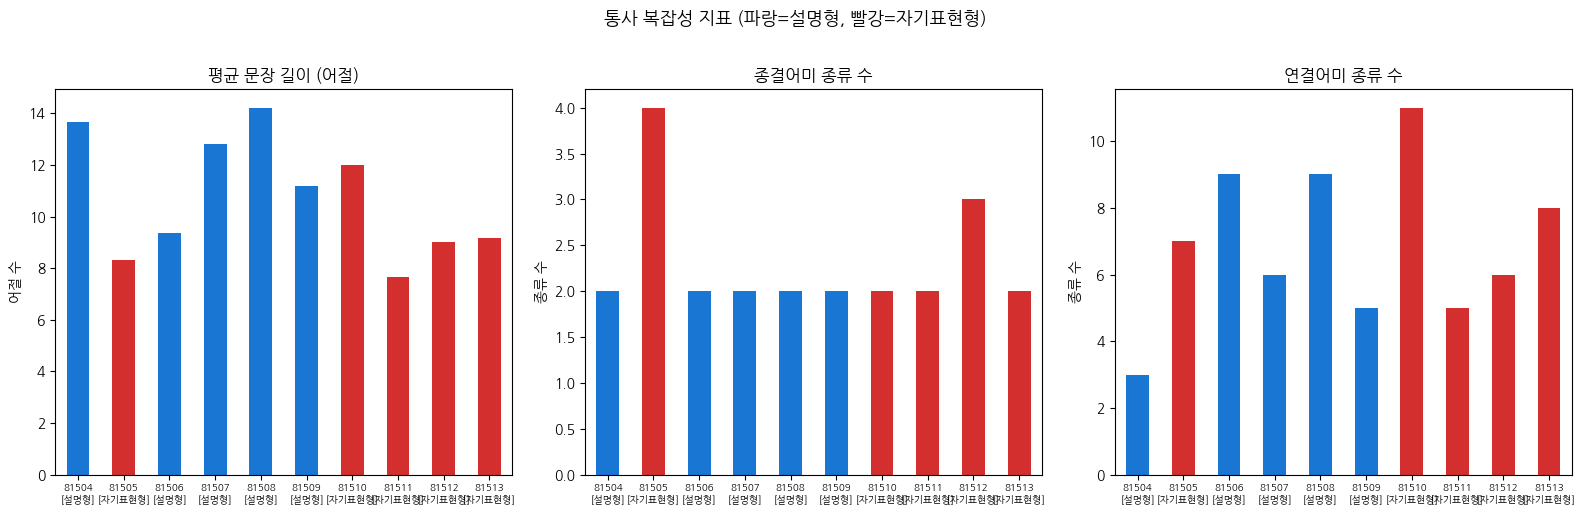

In [ ]:
# 통사 복잡성 종합 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) 평균 문장 길이
df_sent['평균문장길이'].plot(kind='bar', ax=axes[0],
                              color=['#1976D2' if g == '설명형' else '#D32F2F'
                                     for g in df_sent['genre']])
axes[0].set_title('평균 문장 길이 (어절)')
axes[0].set_ylabel('어절 수')
labels = [f"{idx.replace('sample_', '')}\n[{df_sent.loc[idx, 'genre']}]"
          for idx in df_sent.index]
axes[0].set_xticklabels(labels, rotation=0, fontsize=7)

# 2) 종결어미 종류
df_ending['종결어미_종류'].plot(kind='bar', ax=axes[1],
                                  color=['#1976D2' if g == '설명형' else '#D32F2F'
                                         for g in df_meta['genre']])
axes[1].set_title('종결어미 종류 수')
axes[1].set_ylabel('종류 수')
axes[1].set_xticklabels(labels, rotation=0, fontsize=7)

# 3) 연결어미 종류
df_ending['연결어미_종류'].plot(kind='bar', ax=axes[2],
                                  color=['#1976D2' if g == '설명형' else '#D32F2F'
                                         for g in df_meta['genre']])
axes[2].set_title('연결어미 종류 수')
axes[2].set_ylabel('종류 수')
axes[2].set_xticklabels(labels, rotation=0, fontsize=7)

plt.suptitle('통사 복잡성 지표 (파랑=설명형, 빨강=자기표현형)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 장르별 통사 복잡성 평균
syntax_summary = pd.concat([
    df_sent[['genre', '평균문장길이']],
    df_ending[['종결어미_종류', '연결어미_종류', '종결어미_TTR', '연결어미_TTR']]
], axis=1)

print("=" * 50)
print("장르별 통사 복잡성 평균")
print("=" * 50)
print(syntax_summary.groupby('genre').mean(numeric_only=True).round(2).T)

장르별 통사 복잡성 평균
genre       설명형  자기표현형
평균문장길이    12.25   9.23
종결어미_종류    2.00   2.60
연결어미_종류    6.40   7.40
종결어미_TTR   0.19   0.20
연결어미_TTR   0.44   0.44


### 🔍 실습 문제 6

**Q6-1.** **설명형 글**과 **자기표현형 글** 중 어느 쪽이 **평균 문장 길이**가 더 긴가요? 그 이유는 무엇이라고 생각하나요?

**Q6-2.** 텍스트별로 자주 쓰인 **종결어미**를 보세요. '-다' 한 가지에만 의존하는 텍스트가 있나요? 다양한 종결어미를 구사한 텍스트는 어느 것인가요?

**Q6-3.** **연결어미 종류**가 많을수록 글의 어떤 측면이 더 발달했다고 볼 수 있을까요? (힌트: 연결어미는 문장과 문장의 관계를 표현합니다)

**Q6-4.** 이제까지 분석한 모든 지표를 종합해서, **가장 한국어 숙달도가 높아 보이는 텍스트**와 **가장 낮아 보이는 텍스트**를 골라 보세요. 어떤 지표를 근거로 그렇게 판단했나요?

## 📝 수업 시간 과제: 본인 글 분석하기

### 과제 목표
지금까지 배운 **어휘 다양도**와 **통사 복잡성** 지표를 사용해서, 본인이 쓴 한국어 글을 직접 분석해 봅니다.

### 진행 방법
1. **본인의 글 1편 준비**: 자기소개서, 일기, 에세이, 과제 보고서 등 어떤 글이든 좋습니다 (최소 200자 이상 권장)
2. **텍스트 파일(.txt)로 저장**해서 아래 셀에서 업로드
3. **분석 코드 실행** → 자동으로 결과 표와 그래프가 나옵니다
4. **결과 해석 및 보고서 작성** (마지막 셀에 직접 입력)
5. **노트북 전체를 PDF나 캡처로 저장**해서 패들렛에 제출
https://padlet.com/primenh/padlet-146w4x7uscxs1lvb

### 제출 기한
수업 종료 전까지


### 1단계. 본인 글 업로드

아래 셀을 실행하면 **파일 선택 창**이 뜹니다. 본인이 저장한 `.txt` 파일을 선택하세요.

In [ ]:
# 두 개의 글 업로드
from google.colab import files

print("📂 비교할 .txt 파일 2개를 선택하세요.")
print("   (파일 선택 창에서 Ctrl/Cmd 누르고 2개 동시 선택 가능)\n")
uploaded = files.upload()

# 업로드된 파일 개수 확인
if len(uploaded) < 2:
    print(f"\n⚠️ 파일이 {len(uploaded)}개만 업로드됐어요. 2개를 업로드해 주세요.")
else:
    # 두 파일 읽기
    filenames = list(uploaded.keys())
    texts_compare = {}

    for fname in filenames:
        with open(fname, 'r', encoding='utf-8') as f:
            texts_compare[fname] = f.read().strip()

    # 결과 출력
    print("✅ 파일 업로드 완료!\n")
    print("=" * 50)

    for i, (fname, text) in enumerate(texts_compare.items(), 1):
        print(f"\n📄 파일 {i}: {fname}")
        print(f"   글자 수: {len(text)}자")
        print(f"   미리보기 (앞 150자):")
        print(f"   {text[:150]}...")
        print("-" * 50)

📂 비교할 .txt 파일 2개를 선택하세요.
   (파일 선택 창에서 Ctrl/Cmd 누르고 2개 동시 선택 가능)



Saving 이명박_취임사.txt to 이명박_취임사.txt
Saving 노무현_취임사.txt to 노무현_취임사.txt
✅ 파일 업로드 완료!


📄 파일 1: 이명박_취임사.txt
   글자 수: 8852자
   미리보기 (앞 150자):
   존경하는 국민 여러분!
700만 해외동포 여러분!
이 자리에 참석하신 노무현, 김대중, 김영삼, 전두환 전 대통령, 그리고 이슬람 카리모프 우즈베키스탄 대통령, 엥흐바야르 남바르 몽골 대통령, 삼덱 훈센 캄보디아 총리, 후쿠다 야스오 일본 내각 총리대신, 빅토르 주브코...
--------------------------------------------------

📄 파일 2: 노무현_취임사.txt
   글자 수: 5187자
   미리보기 (앞 150자):
   존경하는 국민 여러분.
오늘 저는 대한민국의 제16대 대통령에 취임하기 위해 이 자리에 섰습니다.
국민 여러분의 위대한 선택으로, 저는 대한민국의 새 정부를 운영할 영광스러운 책임을 맡게 되었습니다.
국민 여러분께 뜨거운 감사를 올리면서, 이 벅찬 소명을 국민 여러분과...
--------------------------------------------------


### 2단계. 어휘 다양도 분석

본인 글의 **어휘 다양도(TTR)**를 측정합니다.
- **TTR**(Type-Token Ratio): 전체 단어 중 서로 다른 단어의 비율
- 1에 가까울수록 다양한 어휘 사용, 0에 가까울수록 같은 단어 반복

In [ ]:
# 두 파일의 형태소 분석 + 어휘 다양도 비교
import pandas as pd
from collections import Counter

results = {}
for fname, text in texts_compare.items():
    morphs = get_content_words(text)
    tokens = [w for w, t in morphs]
    type_count = len(set(tokens))
    token_count = len(tokens)
    ttr = type_count / token_count if token_count > 0 else 0

    results[fname] = {
        '토큰수': token_count,
        '타입수': type_count,
        'TTR': round(ttr, 3),
    }
    # 각 파일의 토큰 리스트도 따로 저장 (자주 쓴 단어 확인용)
    results[fname]['_tokens'] = tokens

# 비교 표 출력
print("📊 어휘 다양도 비교 결과")
print("=" * 50)
df_vocab_compare = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if not kk.startswith('_')}
                                  for k, v in results.items()}).T
print(df_vocab_compare)

# TTR 비교 해석
fnames = list(results.keys())
ttr_1 = results[fnames[0]]['TTR']
ttr_2 = results[fnames[1]]['TTR']
print(f"\n📌 TTR 차이: {abs(ttr_1 - ttr_2):.3f}")
if ttr_1 > ttr_2:
    print(f"   → {fnames[0]}이(가) 어휘 다양도가 더 높습니다.")
else:
    print(f"   → {fnames[1]}이(가) 어휘 다양도가 더 높습니다.")

📊 어휘 다양도 비교 결과
                토큰수    타입수    TTR
이명박_취임사.txt  1708.0  833.0  0.488
노무현_취임사.txt   963.0  532.0  0.552

📌 TTR 차이: 0.064
   → 노무현_취임사.txt이(가) 어휘 다양도가 더 높습니다.


In [ ]:
# 각 파일에서 자주 쓴 단어 Top 10 비교
print("📊 자주 쓴 단어 Top 10 비교")
print("=" * 60)

for fname in results:
    tokens = results[fname]['_tokens']
    freq = Counter(tokens).most_common(10)
    print(f"\n📄 {fname}")
    print("-" * 30)
    for word, count in freq:
        print(f"  {word}: {count}회")

📊 자주 쓴 단어 Top 10 비교

📄 이명박_취임사.txt
------------------------------
  국민: 30회
  사회: 22회
  하다: 22회
  있다: 22회
  더: 22회
  나라: 21회
  되다: 18회
  대한민국: 17회
  세계: 17회
  정부: 15회

📄 노무현_취임사.txt
------------------------------
  국민: 21회
  동북아: 18회
  평화: 17회
  시대: 15회
  세계: 13회
  사회: 13회
  위하다: 12회
  한반도: 12회
  북한: 9회
  발전: 9회


### 3단계. 통사 복잡성 분석

본인 글의 **문장 길이**, **종결어미 다양도**, **연결어미 다양도**를 측정합니다.

In [ ]:
# 두 파일의 통사 복잡성 비교
syntax_results = {}

for fname, text in texts_compare.items():
    sent_info = measure_sentence_length(text)
    endings = extract_endings(text)

    syntax_results[fname] = {
        '문장수': sent_info['문장수'],
        '평균문장길이': round(sent_info['평균문장길이'], 2),
        '최장문장': sent_info['최대문장길이'],
        '종결어미_종류': endings['종결어미_종류'],
        '연결어미_종류': endings['연결어미_종류'],
        '연결어미_TTR': round(endings['연결어미_TTR'], 3),
    }
    # 어미 리스트도 저장
    syntax_results[fname]['_final_list'] = endings['_final_list']
    syntax_results[fname]['_connect_list'] = endings['_connect_list']

# 비교 표
print("📊 통사 복잡성 비교 결과")
print("=" * 50)
df_syntax_compare = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if not kk.startswith('_')}
                                   for k, v in syntax_results.items()}).T
print(df_syntax_compare)

# 자주 쓴 어미 확인
print("\n📊 자주 쓴 종결어미·연결어미 비교")
print("=" * 50)
for fname in syntax_results:
    print(f"\n📄 {fname}")
    print(f"  종결어미 Top 5: {Counter(syntax_results[fname]['_final_list']).most_common(5)}")
    print(f"  연결어미 Top 5: {Counter(syntax_results[fname]['_connect_list']).most_common(5)}")

📊 통사 복잡성 비교 결과
               문장수  평균문장길이  최장문장  종결어미_종류  연결어미_종류  연결어미_TTR
이명박_취임사.txt  243.0    8.17  44.0      4.0     31.0     0.090
노무현_취임사.txt  143.0    8.12  25.0      3.0     20.0     0.109

📊 자주 쓴 종결어미·연결어미 비교

📄 이명박_취임사.txt
  종결어미 Top 5: [('ᆸ니다', 139), ('습니다', 91), ('ᆸ시다', 4), ('ᆫ다', 1)]
  연결어미 Top 5: [('고', 85), ('어', 81), ('어야', 58), ('게', 39), ('면', 11)]

📄 노무현_취임사.txt
  종결어미 Top 5: [('습니다', 67), ('ᆸ니다', 64), ('ᆸ시다', 6)]
  연결어미 Top 5: [('어', 59), ('고', 36), ('어야', 30), ('게', 16), ('도록', 8)]


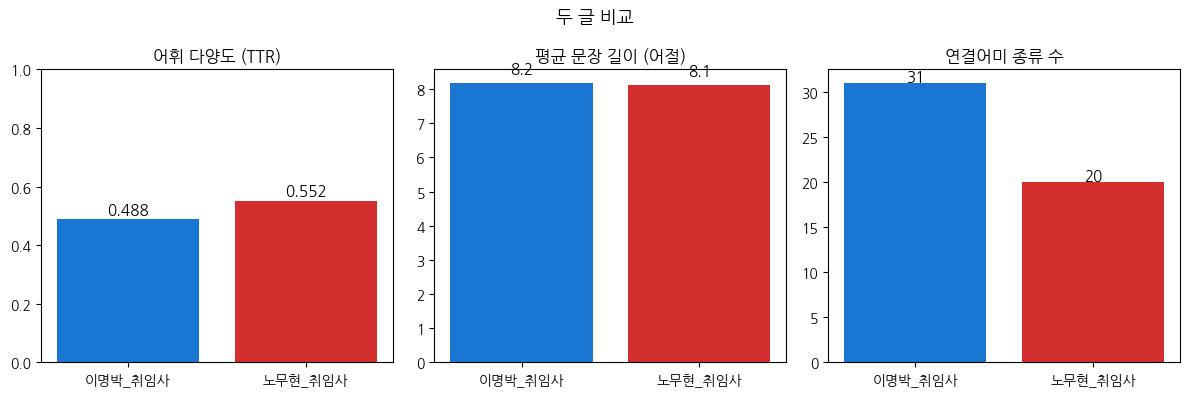

In [ ]:
import matplotlib.pyplot as plt

fnames = list(results.keys())
labels = [f.replace('.txt', '') for f in fnames]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1) TTR
ttrs = [results[f]['TTR'] for f in fnames]
axes[0].bar(labels, ttrs, color=['#1976D2', '#D32F2F'])
axes[0].set_title('어휘 다양도 (TTR)')
axes[0].set_ylim(0, 1)
for i, v in enumerate(ttrs):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

# 2) 평균 문장 길이
mls = [syntax_results[f]['평균문장길이'] for f in fnames]
axes[1].bar(labels, mls, color=['#1976D2', '#D32F2F'])
axes[1].set_title('평균 문장 길이 (어절)')
for i, v in enumerate(mls):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=11)

# 3) 연결어미 종류
ec = [syntax_results[f]['연결어미_종류'] for f in fnames]
axes[2].bar(labels, ec, color=['#1976D2', '#D32F2F'])
axes[2].set_title('연결어미 종류 수')
for i, v in enumerate(ec):
    axes[2].text(i, v + 0.3, f'{v}', ha='center', fontsize=11)

plt.suptitle('두 글 비교', fontsize=13)
plt.tight_layout()
plt.show()

본인 글 분석 - 패들렛에 업로드할 것
https://padlet.com/primenh/padlet-146w4x7uscxs1lvb

In [ ]:
# 본인 글 업로드
from google.colab import files

print("📂 본인이 쓴 글의 .txt 파일을 선택하세요.\n")
uploaded = files.upload()

my_filename = list(uploaded.keys())[0]
with open(my_filename, 'r', encoding='utf-8') as f:
    my_text = f.read().strip()

print(f"✅ 파일 업로드 완료: {my_filename}")
print(f"   글자 수: {len(my_text)}자")

이후 어휘 다양도, 자주 쓴 단어, 통사적 복잡도 계산하여 패들렛에 업로드
https://padlet.com/primenh/padlet-146w4x7uscxs1lvb



### 4단계. 자기 분석 보고서 작성 ✍️

위 결과를 보고 **아래 질문에 직접 답을 작성**하세요.
답은 셀을 더블클릭해서 직접 입력하면 됩니다.

---

**1) 본인이 분석한 글은 어떤 종류의 글인가요?** (예: 자기소개서, 일기, 과제 보고서, SNS 글 등)

👉 답:


**2) 어휘 다양도(TTR) 결과를 어떻게 해석하나요?**
- 자주 쓴 단어 Top 15를 보고 든 생각을 적어주세요.

👉 답:


**3) 통사 복잡성 결과를 어떻게 해석하나요?**
- 평균 문장 길이가 적절하다고 생각하나요?
- 종결어미는 다양하게 썼나요, 아니면 '-다' 한 가지에 집중됐나요?
- 연결어미 종류가 적다면 어떤 어미를 더 써볼 수 있을까요?

👉 답:


**4) 본인 글에서 개선하고 싶은 점 한 가지를 적어주세요.**
- 분석 결과를 근거로 구체적으로 작성해 주세요.

👉 답:
